In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# Import
from pyspark.sql import SparkSession

# Create SparkSession
spark = SparkSession.builder.getOrCreate()
# Read CSV File
spotifydf = spark.read.csv("/content/gdrive/MyDrive/spotify/spotify_data.csv", header=True, inferSchema=True)



In [ ]:
spotifydf.show()

+---+--------------------+--------------------+--------------------+----------+----+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|_c0|         artist_name|          track_name|            track_id|popularity|year|   genre|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+---+--------------------+--------------------+--------------------+----------+----+--------+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|  0|          Jason Mraz|     I Won't Give Up|53QF56cjZA9RTuuMZ...|        68|2012|acoustic|       0.483| 0.303|  4| -10.058|   1|     0.0429|       0.694|             0.0|   0.115|  0.139|133.406|   240166.0|           3.0|
|  1|          Jason Mraz|    93 Million Miles|1s8tP3jP4GZcyHDsj...|        50|2012|acoustic|   

In [ ]:
spotifydf.limit(1000).toPandas()

,_c0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.694,0.0,0.115,0.139,133.406,240166.0,3.0
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.477,1.37e-05,0.0974,0.515,140.182,216387.0,4.0
2,2,Joshua Hyslop,Do Not Let Me Go,7BRCa8MPiyuvr2VU3O9W0F,57,2012,acoustic,0.409,0.234,3,-13.711,1,0.0323,0.338,5e-05,0.0895,0.145,139.832,158960.0,4.0
3,3,Boyce Avenue,Fast Car,63wsZUhUZLlh1OsyrZq7sz,58,2012,acoustic,0.392,0.251,10,-9.845,1,0.0363,0.807,0.0,0.0797,0.508,204.961,304293.0,4.0
4,4,Andrew Belle,Sky's Still Blue,6nXIYClvJAfi6ujLiKqEq8,54,2012,acoustic,0.43,0.791,6,-5.419,0,0.0302,0.0726,0.0193,0.11,0.217,171.864,244320.0,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,El Michels Affair,Incarcerated Scarfaces,1hMySkyDeV8BDayCv3wqVm,32,2012,afrobeat,0.76,0.494,11,-9.391,1,0.042,0.0184,0.828,0.102,0.270,90.258,100493.0,4.0
996,996,El Michels Affair,Protect Ya Neck,1ZhovLmj7HALLd7mhKZFlt,32,2012,afrobeat,0.801,0.779,9,-8.236,1,0.0458,0.0161,0.877,0.0923,0.273,110.966,212867.0,4.0
997,997,The Ogyatanaa Show Band,You Monopolise Me,1FHBkS8AEvnXdXLD9ioUXy,28,2012,afrobeat,0.776,0.554,9,-6.865,1,0.223,0.276,0.0,0.278,0.719,95.482,194427.0,4.0
998,998,Monophonics,Say You Love Me,0umIVhGxcIrwF21ItkFWzY,38,2012,afrobeat,0.703,0.427,9,-8.319,0,0.0424,0.57,6.07e-05,0.137,0.769,89.899,262280.0,4.0


In [ ]:
spotifydf.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_id: string (nullable = true)
 |-- popularity: string (nullable = true)
 |-- year: string (nullable = true)
 |-- genre: string (nullable = true)
 |-- danceability: string (nullable = true)
 |-- energy: string (nullable = true)
 |-- key: string (nullable = true)
 |-- loudness: string (nullable = true)
 |-- mode: string (nullable = true)
 |-- speechiness: string (nullable = true)
 |-- acousticness: string (nullable = true)
 |-- instrumentalness: string (nullable = true)
 |-- liveness: string (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- duration_ms: double (nullable = true)
 |-- time_signature: double (nullable = true)



In [ ]:
spotifydf_no_genre = spotifydf.drop("genre")

In [ ]:
from pyspark.sql.functions import *
from pyspark.sql.types import *

new_spotifydf=spotifydf_no_genre.withColumn('popularity', spotifydf['popularity'].cast(DoubleType())).withColumn('year', spotifydf['year'].cast(IntegerType())).withColumn('danceability', spotifydf['danceability'].cast(DoubleType())).withColumn('energy', spotifydf['energy'].cast(DoubleType())).withColumn('key', spotifydf['key'].cast(IntegerType())).withColumn('loudness', spotifydf['loudness'].cast(DoubleType())).withColumn('mode', spotifydf['mode'].cast(IntegerType())).withColumn('speechiness', spotifydf['speechiness'].cast(DoubleType())).withColumn('acousticness', spotifydf['acousticness'].cast(DoubleType())).withColumn('instrumentalness', spotifydf['instrumentalness'].cast(DoubleType())).withColumn('liveness', spotifydf['liveness'].cast(DoubleType()))

In [ ]:
new_spotifydf.printSchema()

root
 |-- _c0: integer (nullable = true)
 |-- artist_name: string (nullable = true)
 |-- track_name: string (nullable = true)
 |-- track_id: string (nullable = true)
 |-- popularity: double (nullable = true)
 |-- year: integer (nullable = true)
 |-- danceability: double (nullable = true)
 |-- energy: double (nullable = true)
 |-- key: integer (nullable = true)
 |-- loudness: double (nullable = true)
 |-- mode: integer (nullable = true)
 |-- speechiness: double (nullable = true)
 |-- acousticness: double (nullable = true)
 |-- instrumentalness: double (nullable = true)
 |-- liveness: double (nullable = true)
 |-- valence: double (nullable = true)
 |-- tempo: double (nullable = true)
 |-- duration_ms: double (nullable = true)
 |-- time_signature: double (nullable = true)



In [ ]:
new_spotifydf=new_spotifydf.drop("artist_name","track_name","track_id")

In [ ]:
new_spotifydf.show()

+---+----------+----+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|_c0|popularity|year|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|
+---+----------+----+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+
|  0|      68.0|2012|       0.483| 0.303|  4| -10.058|   1|     0.0429|       0.694|             0.0|   0.115|  0.139|133.406|   240166.0|           3.0|
|  1|      50.0|2012|       0.572| 0.454|  3| -10.286|   1|     0.0258|       0.477|         1.37E-5|  0.0974|  0.515|140.182|   216387.0|           4.0|
|  2|      57.0|2012|       0.409| 0.234|  3| -13.711|   1|     0.0323|       0.338|          5.0E-5|  0.0895|  0.145|139.832|   158960.0|           4.0|
|  3|      58.0|2012|       0.392| 0.251| 10|  -9.845|   1|     0.0363|     

In [ ]:
new_spotifydf = new_spotifydf.na.drop()
# یا مقادیر null را با مقدار پیش‌فرض (مثل صفر) پر کنید:
new_spotifydf = new_spotifydf.fillna(0)


In [ ]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt

# 5. تبدیل داده‌ها به فرمت وکتور
assembler = VectorAssembler(inputCols=new_spotifydf.columns, outputCol="features")
spotifydf_features = assembler.transform(new_spotifydf)

In [ ]:
spotifydf_features.limit(100).show()

+---+----------+----+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+--------------------+
|_c0|popularity|year|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|            features|
+---+----------+----+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+--------------------+
|  0|      68.0|2012|       0.483| 0.303|  4| -10.058|   1|     0.0429|       0.694|             0.0|   0.115|  0.139|133.406|   240166.0|           3.0|[0.0,68.0,2012.0,...|
|  1|      50.0|2012|       0.572| 0.454|  3| -10.286|   1|     0.0258|       0.477|         1.37E-5|  0.0974|  0.515|140.182|   216387.0|           4.0|[1.0,50.0,2012.0,...|
|  2|      57.0|2012|       0.409| 0.234|  3| -13.711|   1|     0.0323|       0.338|          5.0E-5|  0.0895|  0.145|139.832

In [ ]:
# نرمال‌سازی داده‌ها
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures")
scaler_model = scaler.fit(spotifydf_features)
spotifydf_scaled = scaler_model.transform(spotifydf_features)

In [ ]:
spotifydf_scaled.limit(10).show()

+---+----------+----+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+--------------------+--------------------+
|_c0|popularity|year|danceability|energy|key|loudness|mode|speechiness|acousticness|instrumentalness|liveness|valence|  tempo|duration_ms|time_signature|            features|      scaledFeatures|
+---+----------+----+------------+------+---+--------+----+-----------+------------+----------------+--------+-------+-------+-----------+--------------+--------------------+--------------------+
|  0|      68.0|2012|       0.483| 0.303|  4| -10.058|   1|     0.0429|       0.694|             0.0|   0.115|  0.139|133.406|   240166.0|           3.0|[0.0,68.0,2012.0,...|[0.0,4.2799025845...|
|  1|      50.0|2012|       0.572| 0.454|  3| -10.286|   1|     0.0258|       0.477|         1.37E-5|  0.0974|  0.515|140.182|   216387.0|           4.0|[1.0,50.0,2012.0,...|[2.33334273591497...|
|  2|      57.0|2012

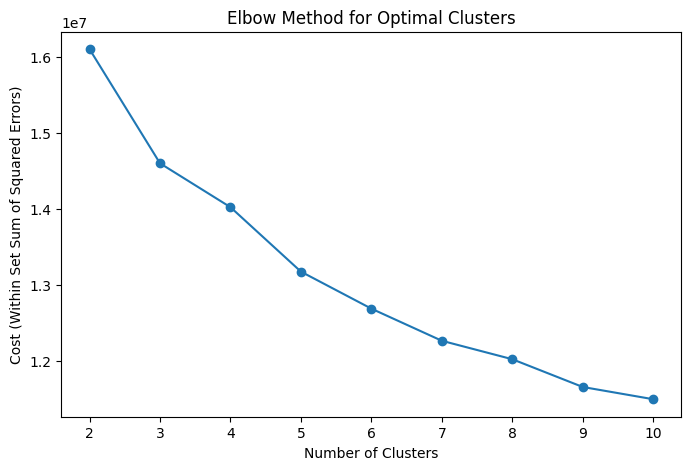

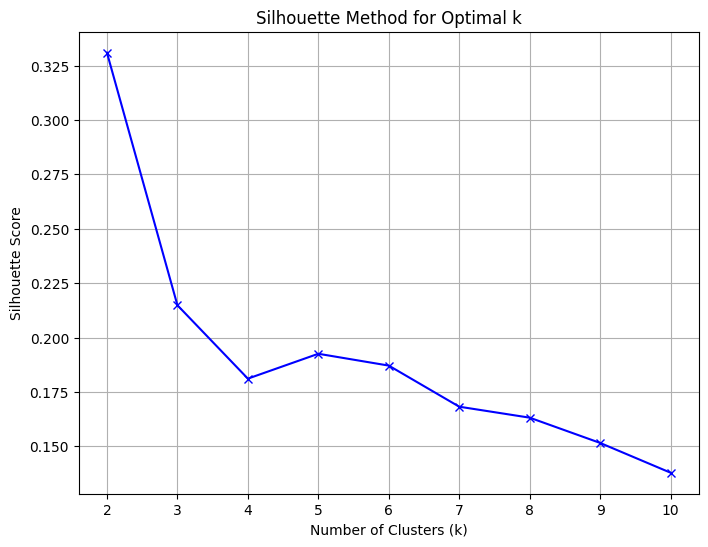

Number of unique genres: 392


In [ ]:
from pyspark.ml.evaluation import ClusteringEvaluator

# elbow و رسم نمودار  k-means  الگوریتم خوشه‌بندی
cost = []
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(featuresCol="scaledFeatures", k=k, seed=1)
    model = kmeans.fit(spotifydf_scaled)
    cost.append(model.summary.trainingCost)

    predictions = model.transform(spotifydf_scaled)
    evaluator = ClusteringEvaluator(featuresCol="scaledFeatures", metricName="silhouette", distanceMeasure="squaredEuclidean")
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)

#  elbow رسم نمودار
plt.figure(figsize=(8, 5))
plt.plot(k_values, cost, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Cost (Within Set Sum of Squared Errors)")
plt.title("Elbow Method for Optimal Clusters")
plt.show()

# 7.  Silhouette رسم نمودار
plt.figure(figsize=(8, 6))
plt.plot(k_values, silhouette_scores, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid()
plt.show()

# به دست آوردن تعداد ژانرهای واقعی
genre_count = spotifydf.select("genre").distinct().count()
print(f"Number of unique genres: {genre_count}")

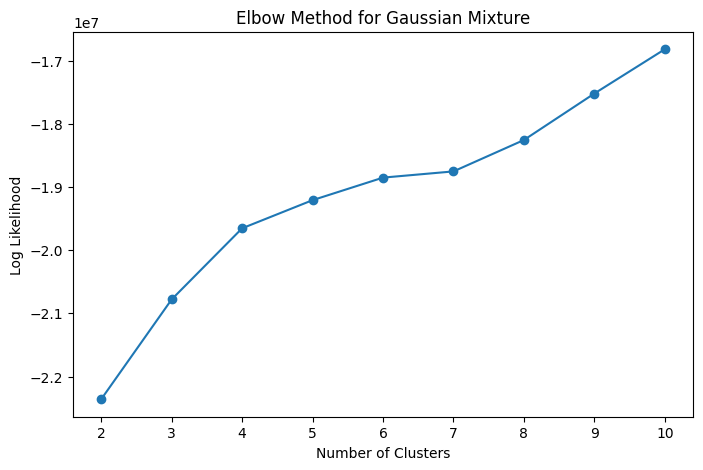

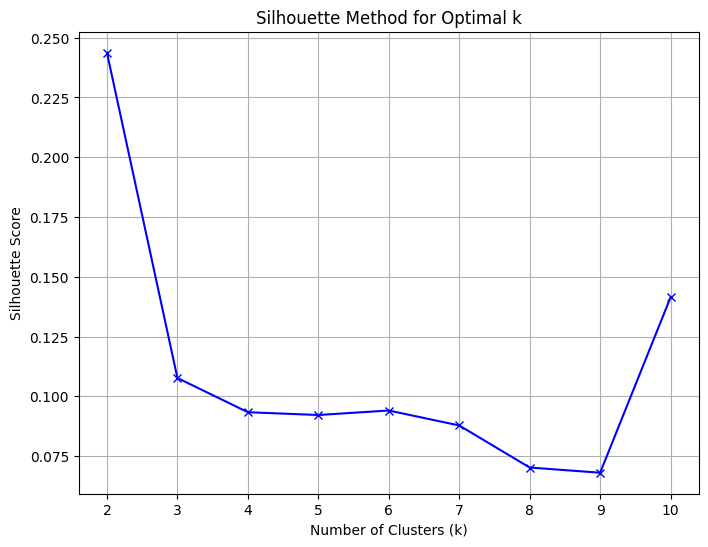

Number of unique genres: 392


In [ ]:
from pyspark.ml.clustering import GaussianMixture
import matplotlib.pyplot as plt

# Gaussian Mixture Model اجرای
cost = []
k_values = range(2, 11)
silhouette_scores = []

for k in k_values:
    gmm = GaussianMixture(featuresCol="scaledFeatures", k=k, seed=1)
    model = gmm.fit(spotifydf_scaled)
    log_likelihood = model.summary.logLikelihood
    cost.append(log_likelihood)

    predictions = model.transform(spotifydf_scaled)
    evaluator = ClusteringEvaluator(featuresCol="scaledFeatures", metricName="silhouette", distanceMeasure="squaredEuclidean")
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append(silhouette)

# elbow رسم نمودار
plt.figure(figsize=(8, 5))
plt.plot(k_values, cost, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Log Likelihood")
plt.title("Elbow Method for Gaussian Mixture")
plt.show()

# 7. Silhouette رسم نمودار
plt.figure(figsize=(8, 6))
plt.plot(k_values, silhouette_scores, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.grid()
plt.show()


In [ ]:
# نمونه‌گیری 25 درصد از داده‌ها
sampled_data = spotifydf_scaled.sample(withReplacement=False, fraction=0.25, seed=42)

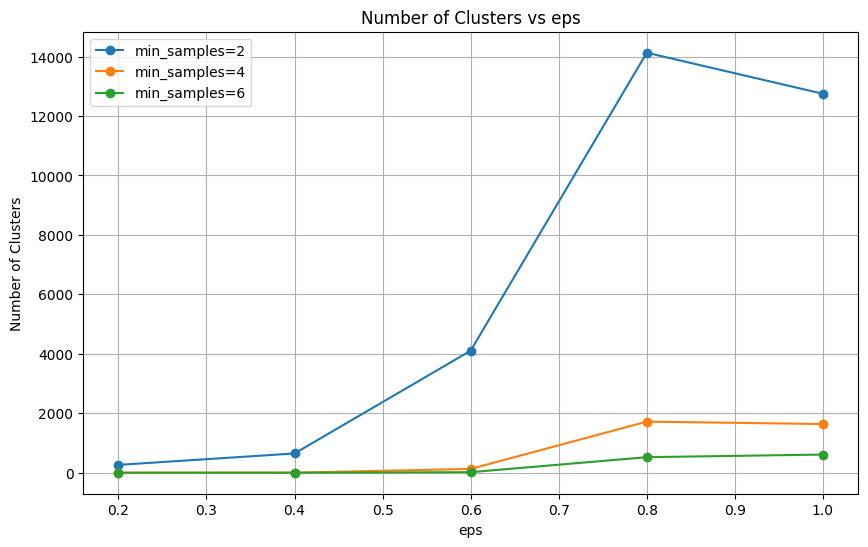

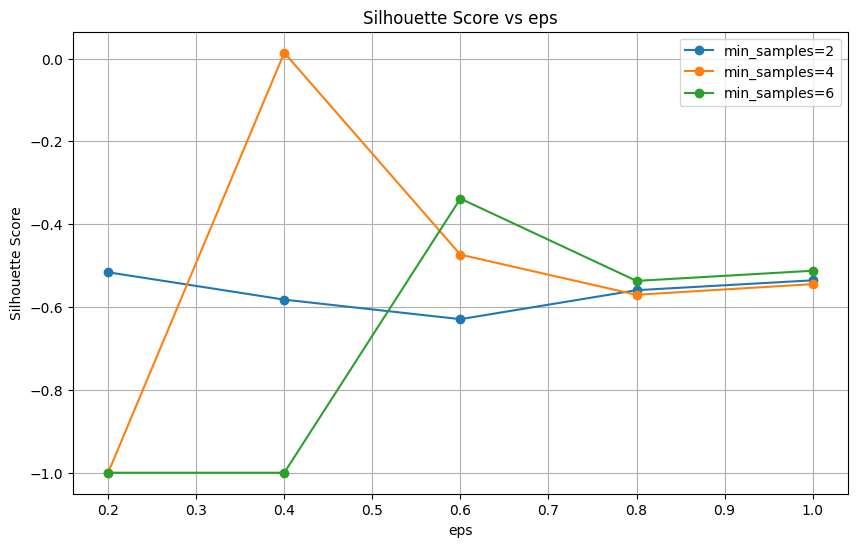

In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Pandas تبدیل داده‌ها به
data_pandas = sampled_data.select("scaledFeatures").toPandas()
features = data_pandas["scaledFeatures"].apply(lambda x: x.toArray()).tolist()

# استانداردسازی داده‌ها
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# eps و min_samples محدوده پارامترهای
eps_values = [0.2, 0.4, 0.6, 0.8, 1.0]
min_samples_values = [2, 4, 6]

# نگهداری نتایج
results = []

# eps و min_samples حلقه روی پارامترهای
for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(scaled_features)

        # تعداد خوشه‌ها
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # حذف نویز (-1)
        n_noise = list(labels).count(-1)

        # (در صورت وجود بیش از یک خوشه ) Silhouette Score  محاسبه
        if n_clusters > 1:
            silhouette = silhouette_score(scaled_features, labels)
        else:
            silhouette = -1  # مقدار غیر معتبر

        results.append((eps, min_samples, n_clusters, silhouette, n_noise))

# DataFrame تبدیل نتایج به
results_df = pd.DataFrame(results, columns=["eps", "min_samples", "n_clusters", "silhouette_score", "n_noise"])

# رسم نمودارها
# 1. نمودار تعداد خوشه‌ها
plt.figure(figsize=(10, 6))
for min_samples in min_samples_values:
    subset = results_df[results_df["min_samples"] == min_samples]
    plt.plot(subset["eps"], subset["n_clusters"], marker='o', label=f'min_samples={min_samples}')
plt.title('Number of Clusters vs eps')
plt.xlabel('eps')
plt.ylabel('Number of Clusters')
plt.legend()
plt.grid(True)
plt.show()

# 2. Silhouette Score نمودار
plt.figure(figsize=(10, 6))
for min_samples in min_samples_values:
    subset = results_df[results_df["min_samples"] == min_samples]
    plt.plot(subset["eps"], subset["silhouette_score"], marker='o', label=f'min_samples={min_samples}')
plt.title('Silhouette Score vs eps')
plt.xlabel('eps')
plt.ylabel('Silhouette Score')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.10/dist-packages/pyspark/ml/clustering.py:1016: FutureWarning: Deprecated in 3.0.0. It will be removed in future versions. Use ClusteringEvaluator instead. You can also get the cost on the training dataset in the summary.
  warnings.warn(


Costs: [16097900.346781012, 14660418.275060039, 14626036.42369084, 13861714.639545307, 13358673.570343062, 13106353.005975526, 12872596.846239196, 12586513.876828708, 12298958.583163437]
Silhouette Scores: [(2, 0.029749222071640033), (3, 0.365506474811827), (4, -0.04914478422941228), (5, -0.11856154168148623), (6, -0.11919640986710424), (7, -0.1193640695156512), (8, -0.2896845815141085), (9, -0.32418944833298824), (10, -0.3241287571379678)]


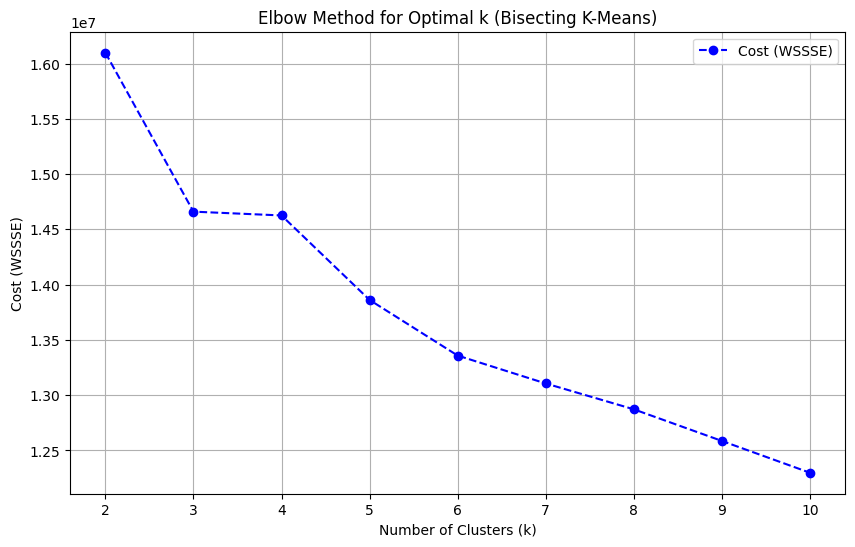

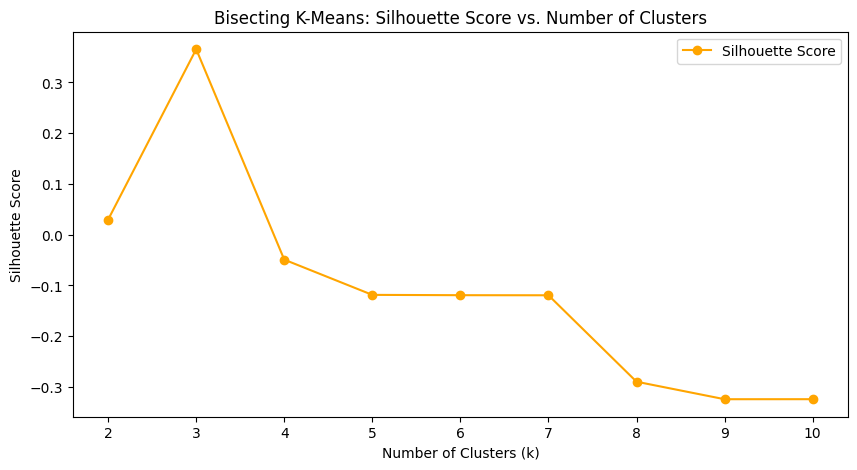

In [ ]:
from pyspark.ml.clustering import BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt

# ستون ویژگی ها
features_col = "scaledFeatures"

# k لیست مقادیر
k_values = range(2, 11)  # از 2 تا 10 خوشه

# نگهداری مقادیر هزینه
costs = []
silhouette_scores = []

# k حلقه روی مقادیر مختلف
for k in k_values:
    bkm = BisectingKMeans().setK(k).setSeed(1).setFeaturesCol(features_col)
    model = bkm.fit(spotifydf_scaled)

    # (Within Set Sum of Squared Errors) هزینه خوشه‌بندی
    cost = model.computeCost(spotifydf_scaled)
    costs.append(cost)

    # silhouette score ارزیابی با
    predictions = model.transform(spotifydf_scaled)
    evaluator = ClusteringEvaluator()
    silhouette = evaluator.evaluate(predictions)
    silhouette_scores.append((k, silhouette))

# نمایش نتایج
print("Costs:", costs)
print("Silhouette Scores:", silhouette_scores)

# Elbow رسم نمودار
plt.figure(figsize=(10, 6))
plt.plot(k_values, costs, marker='o', linestyle='--', color='b', label='Cost (WSSSE)')
plt.title('Elbow Method for Optimal k (Bisecting K-Means)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Cost (WSSSE)')
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()

# silhouette score  رسم نمودار
k_vals, sil_vals = zip(*silhouette_scores)
plt.figure(figsize=(10, 5))
plt.plot(k_vals, sil_vals, marker='o', color='orange', label='Silhouette Score')
plt.title('Bisecting K-Means: Silhouette Score vs. Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.legend()
plt.show()